# ERM untied exp

In [32]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

In [33]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'figure.dpi': 300,
    'savefig.bbox': 'tight',
})

In [34]:
run_id_S = "20251212_1957" # S 
run_id_tied = "20251213_1322" # tied
run_id_untied_1 = "20251212_2158" # untied rho - 1.0
run_id_untied_075 = "20251213_1005" # untied rho - 0.75
run_id_untied_15 = "20251213_1804" # untied rho - 1.5
run_id_untied_05 = "20251215_1148" # untied rho - 0.5

run_dir_S = f"../results/run_{run_id_S}/"
config_path_S = f"../results/run_{run_id_S}/config.csv"
base_path_S = f"../results/run_{run_id_S}/summary.csv"

run_dir_tied = f"../results/run_{run_id_tied}/"
config_path_tied = f"../results/run_{run_id_tied}/config.csv"
base_path_tied = f"../results/run_{run_id_tied}/summary.csv"

run_dir_untied_1 = f"../results/run_{run_id_untied_1}/"
config_path_untied_1 = f"../results/run_{run_id_untied_1}/config.csv"
base_path_untied_1 = f"../results/run_{run_id_untied_1}/summary.csv"

run_dir_untied_075 = f"../results/run_{run_id_untied_075}/"
config_path_untied_075 = f"../results/run_{run_id_untied_075}/config.csv"
base_path_untied_075 = f"../results/run_{run_id_untied_075}/summary.csv"

run_dir_untied_15 = f"../results/run_{run_id_untied_15}/"
config_path_untied_15 = f"../results/run_{run_id_untied_15}/config.csv"
base_path_untied_15 = f"../results/run_{run_id_untied_15}/summary.csv"

run_dir_untied_05 = f"../results/run_{run_id_untied_05}/"
config_path_untied_05 = f"../results/run_{run_id_untied_05}/config.csv"
base_path_untied_05 = f"../results/run_{run_id_untied_05}/summary.csv"

plot_path = f"../results/Synthetic_experiments_plots/"
os.makedirs(plot_path, exist_ok=True)

Loaded:
  S             : 75 rows
  Tied          : 90 rows
  Untied (1.0)  : 105 rows
  Untied (0.75) : 105 rows
  Untied (1.5)  : 105 rows
  Untied (0.5)  : 105 rows

Using λ = 0.0001
  S rows             = 15
  Tied rows          = 15
  Untied (1.0) rows  = 15
  Untied (0.75) rows = 15
  Untied (1.5) rows  = 15
  Untied (0.5) rows  = 15
✅ Plotting 'Unfactorized' (15 points)
✅ Plotting 'Tied' (15 points)
✅ Plotting 'Untied ($\rho=0.5$)' (15 points)
✅ Plotting 'Untied ($\rho=0.75$)' (15 points)
✅ Plotting 'Untied ($\rho=1.0$)' (15 points)
✅ Plotting 'Untied ($\rho=1.5$)' (15 points)

✅ Graphique sauvegardé : ../results/Synthetic_experiments_plots/LabelError_All_Comparison_lambda0.0001.png


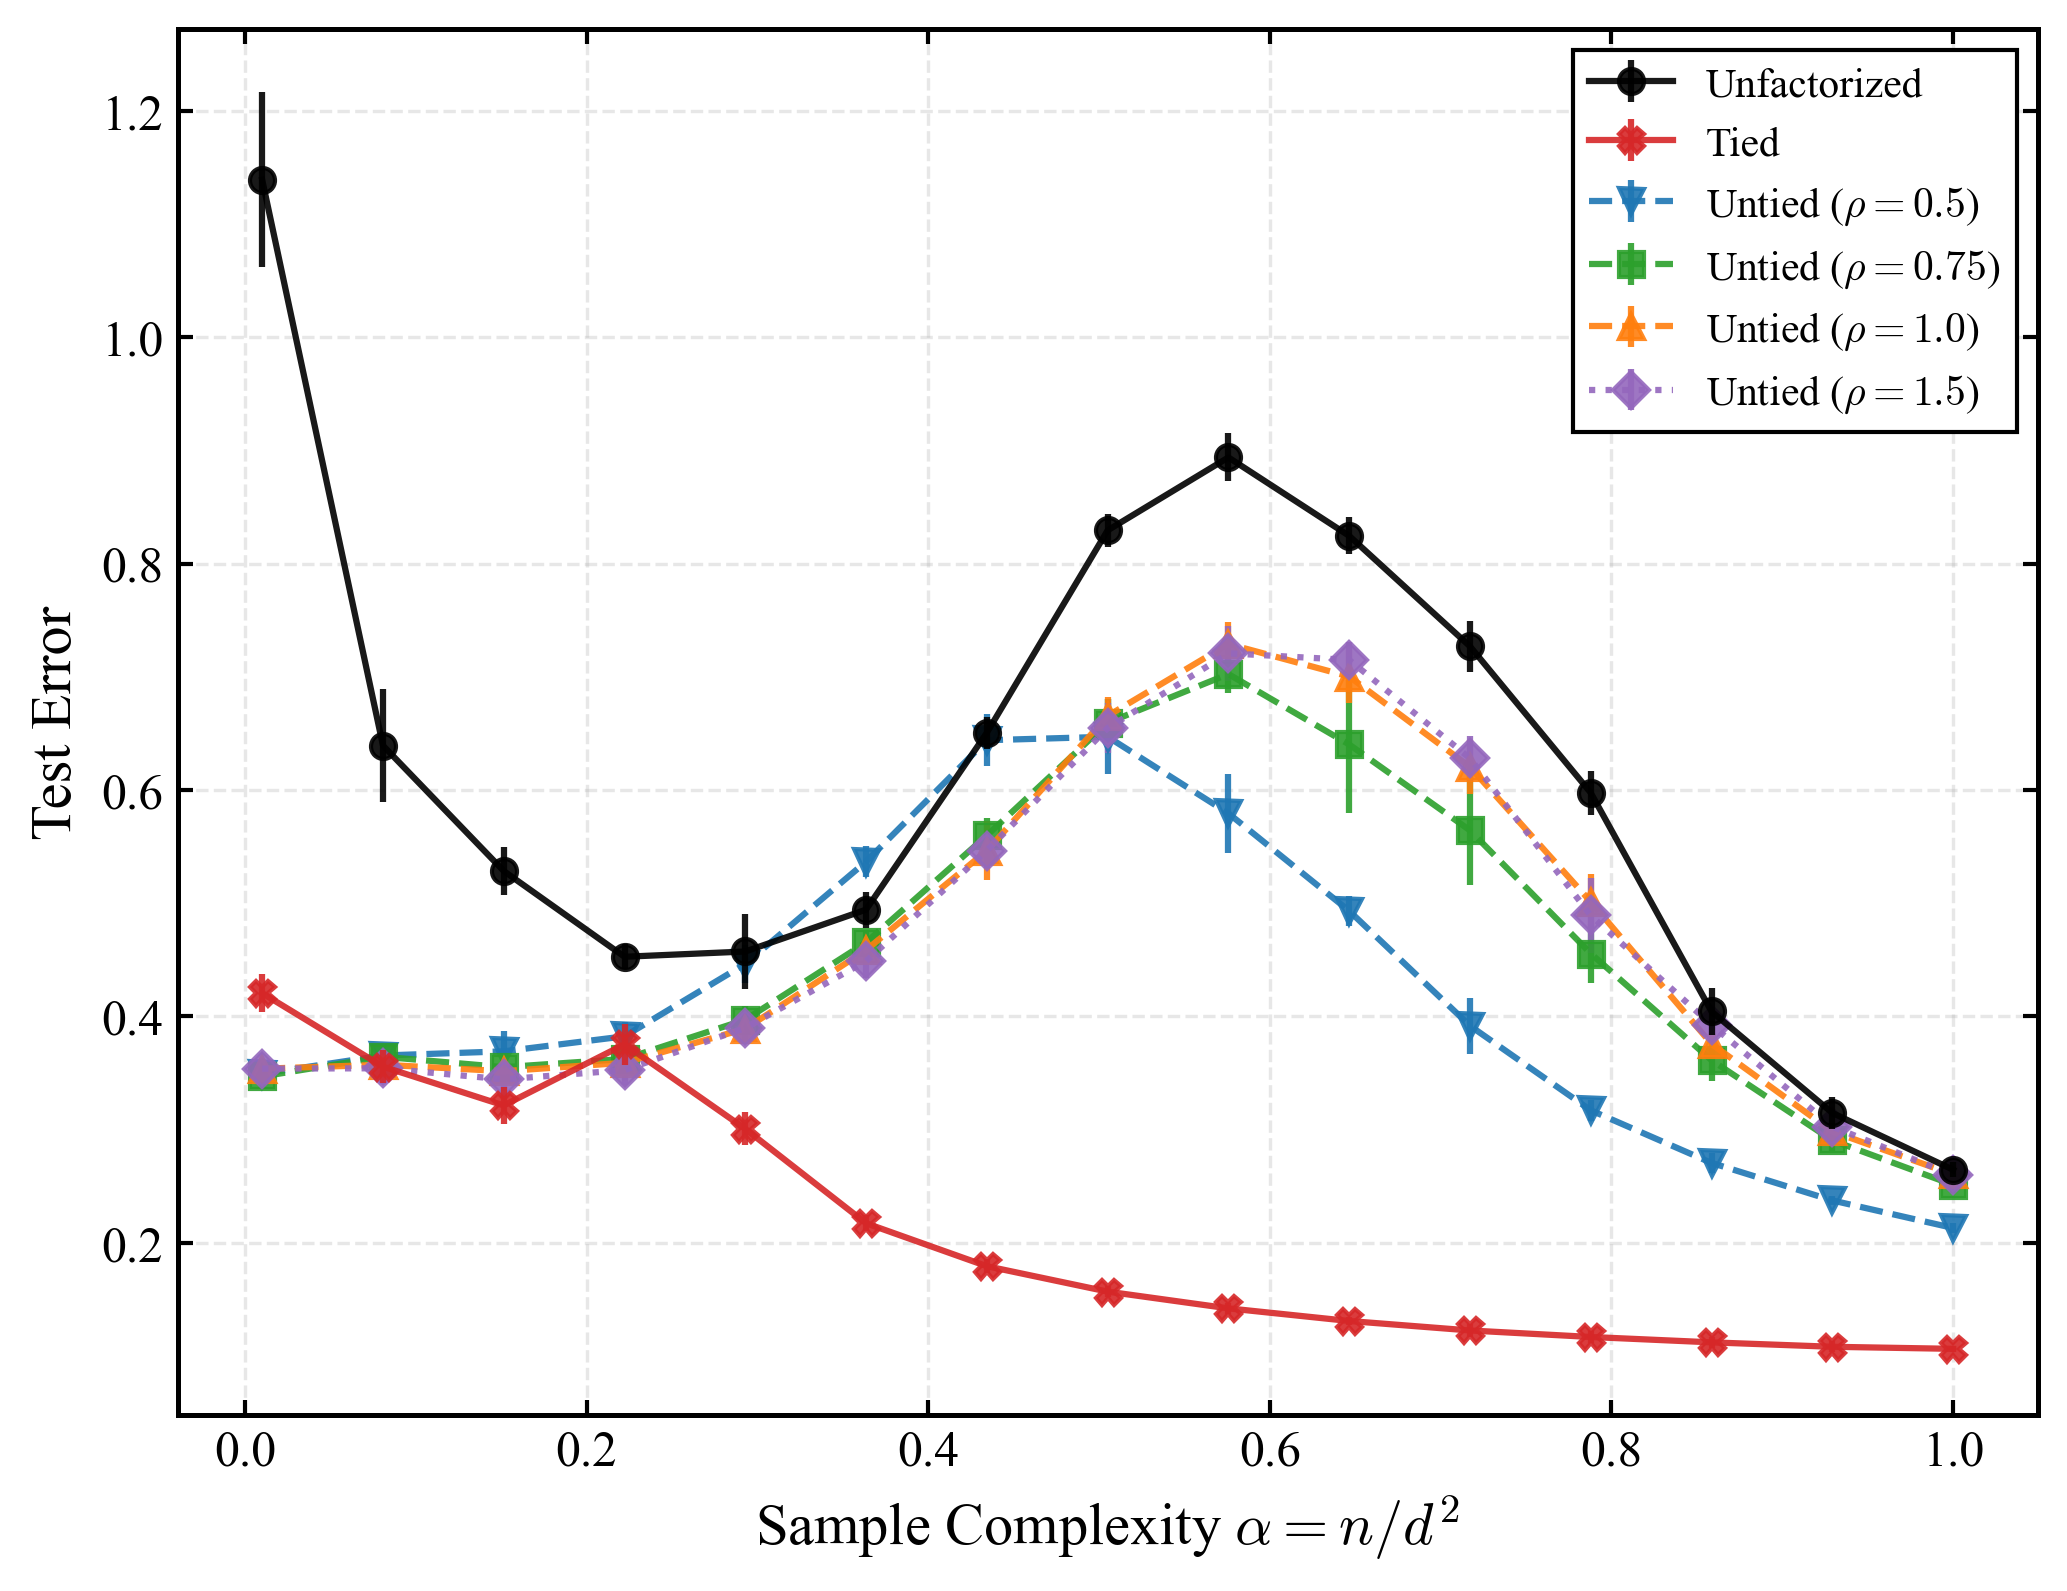

In [35]:
from email.mime import base
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# Construction des chemins
base_path_S = f"../results/run_{run_id_S}/summary.csv"
base_path_tied = f"../results/run_{run_id_tied}/summary.csv"
base_path_untied_1 = f"../results/run_{run_id_untied_1}/summary.csv"
base_path_untied_075 = f"../results/run_{run_id_untied_075}/summary.csv"
base_path_untied_15 = f"../results/run_{run_id_untied_15}/summary.csv"
base_path_untied_05 = f"../results/run_{run_id_untied_05}/summary.csv"

# --- 2. CHOIX DU LAMBDA ---
lam_fixed = 0.0001

# --- 3. CHARGEMENT DES DONNÉES ---
# On ajoute le try/except pour éviter que ça plante si un fichier manque
try:
    df_S = pd.read_csv(base_path_S)
    df_tied = pd.read_csv(base_path_tied)  
    df_untied_1 = pd.read_csv(base_path_untied_1)
    df_untied_075 = pd.read_csv(base_path_untied_075)
    df_untied_15 = pd.read_csv(base_path_untied_15)
    df_untied_05 = pd.read_csv(base_path_untied_05)
except FileNotFoundError as e:
    print(f"❌ Erreur : Fichier introuvable. Vérifiez les chemins.\n{e}")
    exit()

print("Loaded:")
print(f"  S             : {len(df_S)} rows")
print(f"  Tied          : {len(df_tied)} rows") 
print(f"  Untied (1.0)  : {len(df_untied_1)} rows")
print(f"  Untied (0.75) : {len(df_untied_075)} rows")
print(f"  Untied (1.5)  : {len(df_untied_15)} rows")
print(f"  Untied (0.5)  : {len(df_untied_05)} rows")

# --- 4. FILTRAGE PAR LAMBDA ---
df_S_f = df_S[df_S["lam"] == lam_fixed].sort_values("alpha")
df_tied_f = df_tied[df_tied["lam"] == lam_fixed].sort_values("alpha") # <--- Ajouté
df_untied_1_f = df_untied_1[df_untied_1["lam"] == lam_fixed].sort_values("alpha")
df_untied_075_f = df_untied_075[df_untied_075["lam"] == lam_fixed].sort_values("alpha")
df_untied_15_f = df_untied_15[df_untied_15["lam"] == lam_fixed].sort_values("alpha")
df_untied_05_f = df_untied_05[df_untied_05["lam"] == lam_fixed].sort_values("alpha")

print(f"\nUsing λ = {lam_fixed}")
print(f"  S rows             = {len(df_S_f)}")
print(f"  Tied rows          = {len(df_tied_f)}")
print(f"  Untied (1.0) rows  = {len(df_untied_1_f)}")
print(f"  Untied (0.75) rows = {len(df_untied_075_f)}")
print(f"  Untied (1.5) rows  = {len(df_untied_15_f)}")
print(f"  Untied (0.5) rows  = {len(df_untied_05_f)}")

# --- 2. Configuration ---
lam_fixed = 0.0001

# Définition des expériences à tracer
# Structure: "Label": (chemin_fichier, couleur, marqueur, style_ligne)
experiments = {
    "Unfactorized": {
        "path": f"../results/run_{run_id_S}/summary.csv",
        "color": "black", "marker": "o", "ls": "-"
    },
    "Tied": {
        "path": f"../results/run_{run_id_tied}/summary.csv",
        "color": "#d62728", "marker": "X", "ls": "-" # Rouge
    },
    r"Untied ($\rho=0.5$)": {
        "path": f"../results/run_{run_id_untied_05}/summary.csv",
        "color": "#1f77b4", "marker": "v", "ls": "--" # Bleu foncé
    },
    r"Untied ($\rho=0.75$)": {
        "path": f"../results/run_{run_id_untied_075}/summary.csv",
        "color": "#2ca02c", "marker": "s", "ls": "--" # Vert
    },
    r"Untied ($\rho=1.0$)": {
        "path": f"../results/run_{run_id_untied_1}/summary.csv",
        "color": "#ff7f0e", "marker": "^", "ls": "--" # Orange
    },
    r"Untied ($\rho=1.5$)": {
        "path": f"../results/run_{run_id_untied_15}/summary.csv",
        "color": "#9467bd", "marker": "D", "ls": ":" # Violet
    }
}

# --- 3. Chargement et Plot ---
plt.figure(figsize=(8, 6))

data_found = False # Pour vérifier si on a tracé au moins un truc

for label, config in experiments.items():
    path = config["path"]
    
    # 1. Vérification du fichier
    if not os.path.exists(path):
        print(f"⚠️ Warning: File not found for '{label}': {path}")
        continue
        
    try:
        # 2. Chargement
        df = pd.read_csv(path)
        
        # 3. Filtrage par lambda
        subset = df[df["lam"] == lam_fixed].sort_values("alpha")
        
        if subset.empty:
            print(f"⚠️ Warning: No data for lambda={lam_fixed} in '{label}'")
            continue
            
        print(f"✅ Plotting '{label}' ({len(subset)} points)")
        data_found = True
        
        # 4. Plotting
        # Astuce: zorder permet de mettre certaines courbes au dessus des autres
        # On met souvent la courbe de référence (Unfactorized ou Tied) au premier plan
        z_ord = 10 if "Unfactorized" in label or "Tied" in label else 5
        
        plt.errorbar(
            subset["alpha"],
            subset["label_err_mean_noise"],
            yerr=subset.get("label_err_std_noise", 0),
            label=label,
            color=config["color"],
            marker=config["marker"],
            linestyle=config["ls"],
            capsize=0,      
            elinewidth=1.5,
            alpha=0.9,
            zorder=z_ord
        )
        
    except Exception as e:
        print(f"❌ Error processing '{label}': {e}")

# --- 4. Mise en forme finale ---
if not data_found:
    print("❌ No data was plotted. Check paths and lambda.")
else:
    plt.xlabel(r"Sample Complexity $\alpha = n / d^2$")
    plt.ylabel("Test Error")
    
    # --- STYLE BOÎTE (Box Style) ---
    ax = plt.gca()
    ax.set_axisbelow(True) # Grille derrière
    ax.tick_params(direction='in', top=True, right=True, which='both', width=1.0)
    
    # Bordures noires solides
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.2)
    
    # Légende propre
    plt.legend(frameon=True, fancybox=False, edgecolor='black', framealpha=1.0, loc='best')

    # Sauvegarde
    filename = f"LabelError_All_Comparison_lambda{lam_fixed}.png"
    # Assure-toi que plot_path est défini, sinon utilise repertoire courant
    save_dir = plot_path if 'plot_path' in locals() else "." 
    save_full = os.path.join(save_dir, filename)
    
    plt.savefig(save_full)
    print(f"\n✅ Graphique sauvegardé : {save_full}")
    plt.show()

✅ Loaded 'Untied ($\rho=0.5$)': 15 rows
✅ Loaded 'Untied ($\rho=0.75$)': 15 rows
✅ Loaded 'Untied ($\rho=1.0$)': 15 rows
✅ Loaded 'Untied ($\rho=1.5$)': 15 rows

✅ Graphique sauvegardé : ../results/Synthetic_experiments_plots/LabelError_Untied_Comparison_lambda0.0001.png


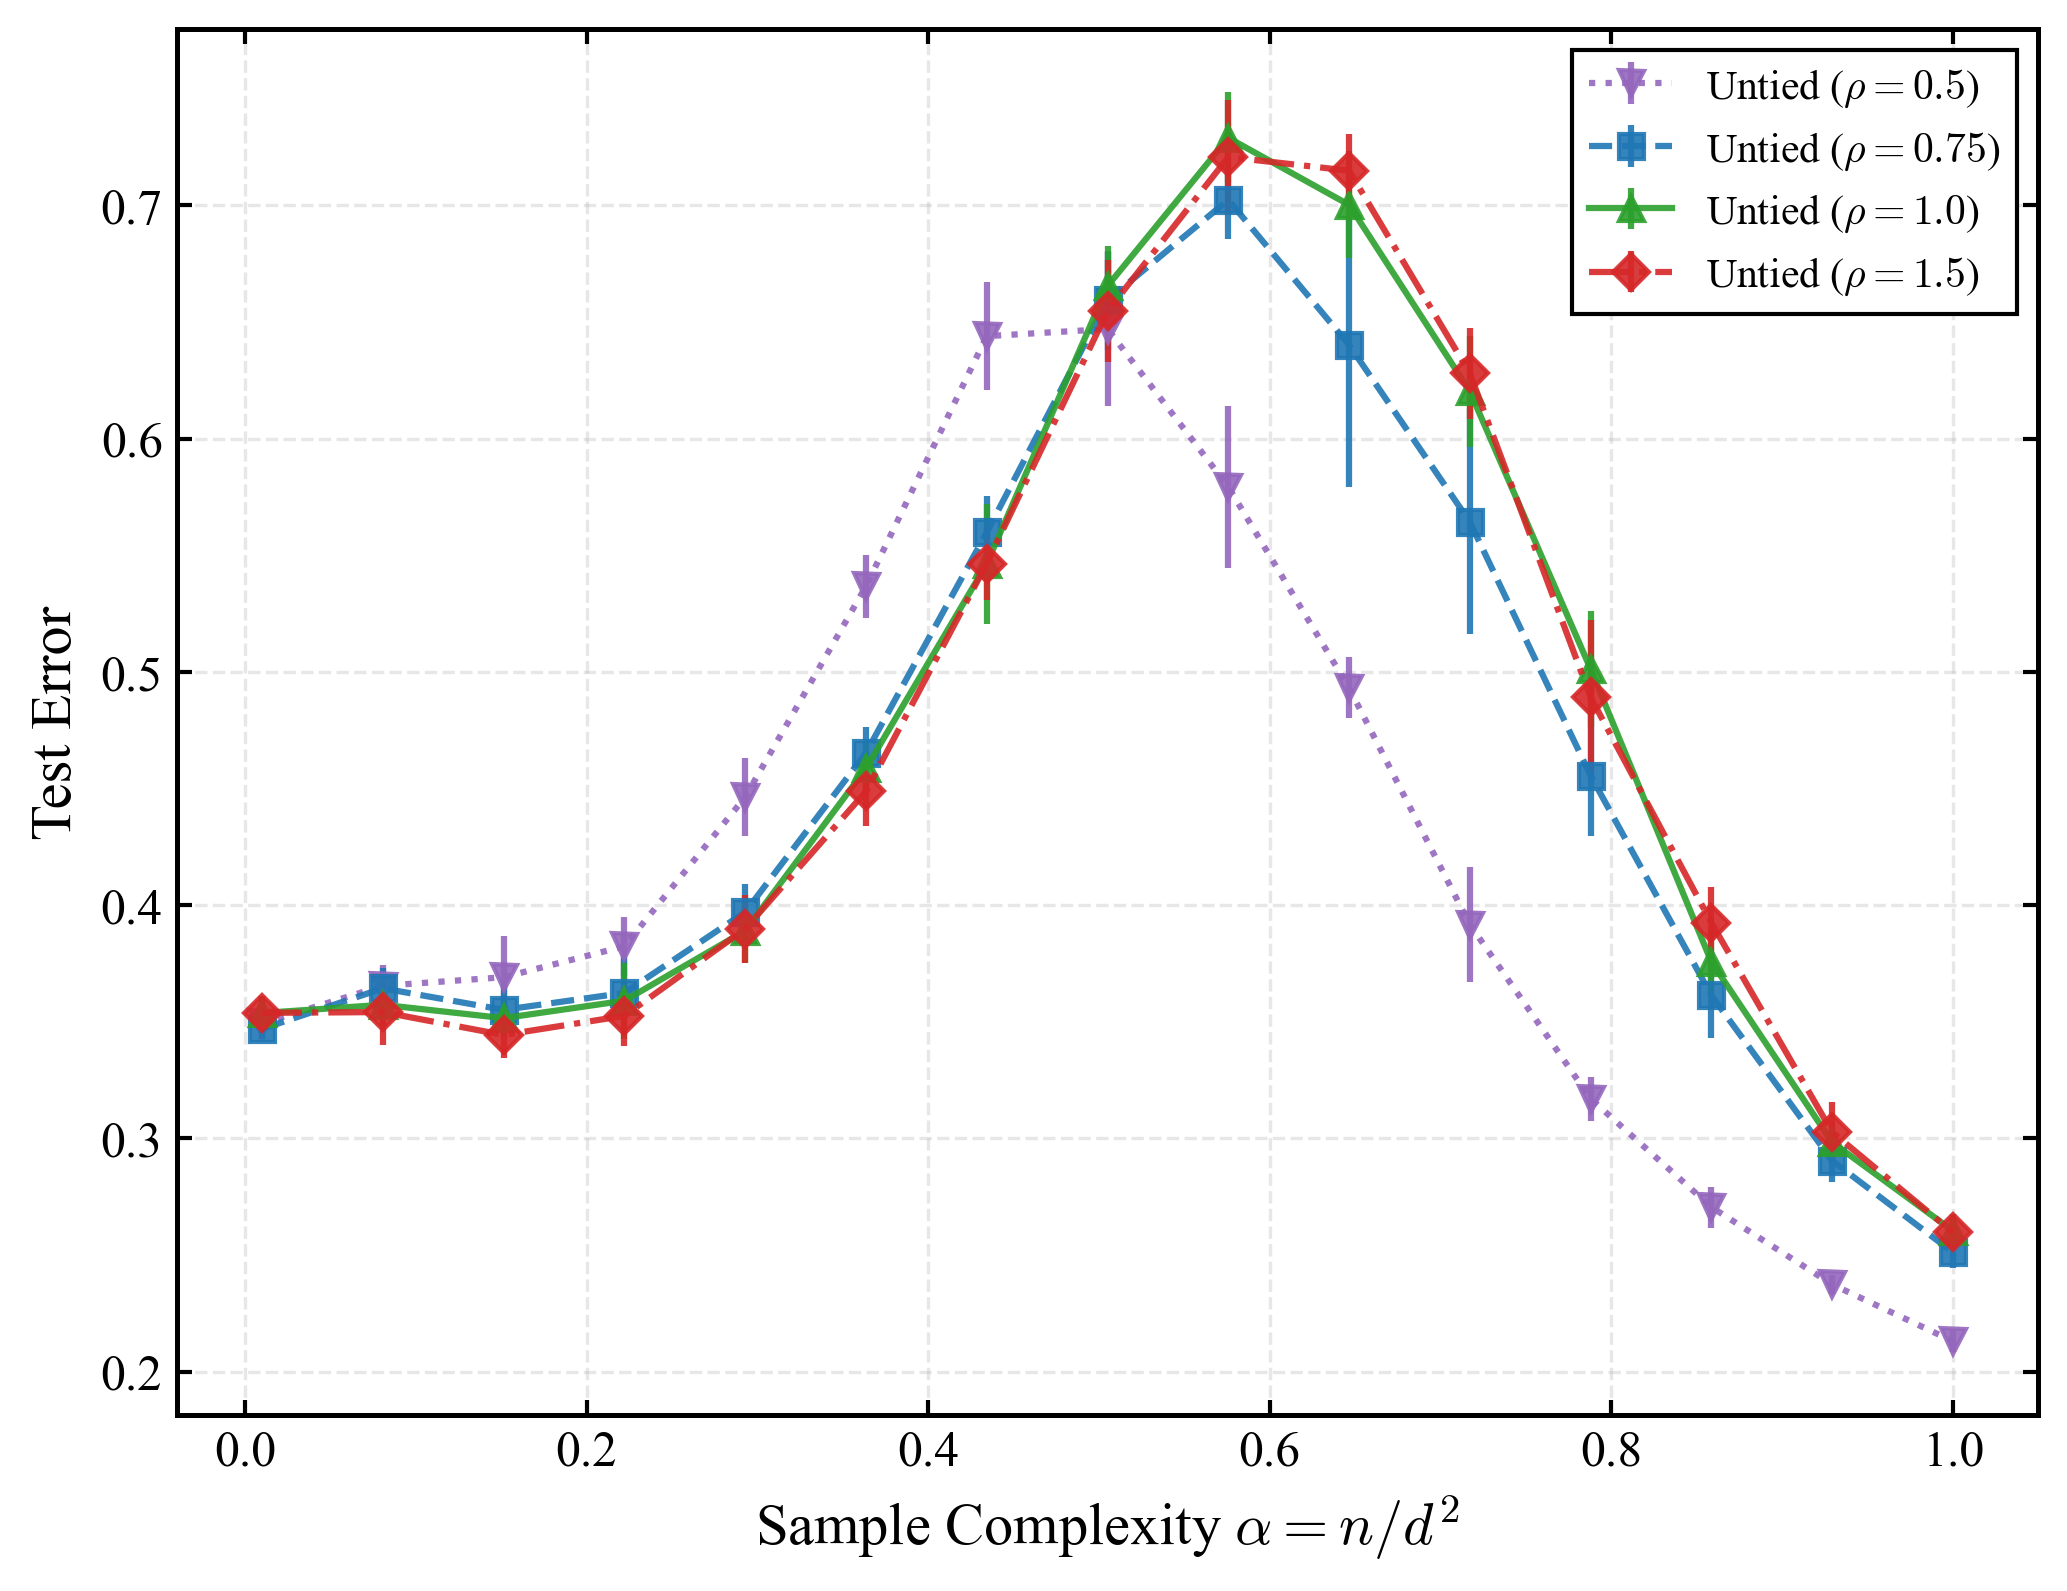

In [36]:
# --- 2. Configuration ---
lam_fixed = 0.0001

# Définition des expériences à tracer (Seulement les "Untied")
# On utilise une palette progressive pour voir l'effet de Rho
experiments = {
    r"Untied ($\rho=0.5$)": {
        "path": f"../results/run_{run_id_untied_05}/summary.csv",
        "color": "#9467bd", "marker": "v", "ls": ":" # Violet
    },
    r"Untied ($\rho=0.75$)": {
        "path": f"../results/run_{run_id_untied_075}/summary.csv",
        "color": "#1f77b4", "marker": "s", "ls": "--" # Bleu
    },
    r"Untied ($\rho=1.0$)": {
        "path": f"../results/run_{run_id_untied_1}/summary.csv",
        "color": "#2ca02c", "marker": "^", "ls": "-" # Vert (Référence)
    },
    r"Untied ($\rho=1.5$)": {
        "path": f"../results/run_{run_id_untied_15}/summary.csv",
        "color": "#d62728", "marker": "D", "ls": "-." # Rouge
    }
}

# --- 3. Chargement et Plot ---
plt.figure(figsize=(8, 6))

data_found = False 

for label, config in experiments.items():
    path = config["path"]
    
    # Vérification fichier
    if not os.path.exists(path):
        print(f"⚠️ Fichier introuvable pour '{label}': {path}")
        continue
        
    try:
        # Chargement
        df = pd.read_csv(path)
        
        # Filtrage par lambda
        subset = df[df["lam"] == lam_fixed].sort_values("alpha")
        
        if subset.empty:
            print(f"⚠️ Pas de données pour lambda={lam_fixed} dans '{label}'")
            continue
            
        print(f"✅ Loaded '{label}': {len(subset)} rows")
        data_found = True
        
        # Plotting
        plt.errorbar(
            subset["alpha"],
            subset["label_err_mean_noise"],
            yerr=subset.get("label_err_std_noise", 0),
            label=label,
            color=config["color"],
            marker=config["marker"],
            linestyle=config["ls"],
            capsize=0,
            elinewidth=1.5,
            alpha=0.9
        )
        
    except Exception as e:
        print(f"❌ Erreur sur '{label}': {e}")

# --- 4. Mise en forme finale ---
if data_found:
    plt.xlabel(r"Sample Complexity $\alpha = n / d^2$")
    plt.ylabel("Test Error")
    
    # --- STYLE BOÎTE (Box Style) ---
    ax = plt.gca()
    ax.set_axisbelow(True) # Grille derrière
    
    # Ticks à l'intérieur sur les 4 côtés
    ax.tick_params(direction='in', top=True, right=True, which='both', width=1.0)
    
    # Bordures noires
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.2)
    
    # Légende
    plt.legend(frameon=True, fancybox=False, edgecolor='black', framealpha=1.0, loc='best')

    # Sauvegarde
    filename = f"LabelError_Untied_Comparison_lambda{lam_fixed}.png"
    # save_dir = plot_path if 'plot_path' in locals() else "."
    save_full = os.path.join(plot_path, filename)
    
    plt.savefig(save_full)
    print(f"\n✅ Graphique sauvegardé : {save_full}")
    plt.show()
else:
    print("\n❌ Aucun graphique généré (vérifiez les chemins ou le lambda).")